# Install dependencies and environment setup

In [1]:
%pip -qqq install miditoolkit kagglehub scikit-learn torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.9 MB/s eta 0:00:00


In [2]:
# Dependencies
from __future__ import annotations

import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

from bisect import bisect_right
import copy
import glob
import hashlib
import json
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
from miditoolkit import MidiFile
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [3]:
# Check if PyTorch can access an NVIDIA GPU through CUDA
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


# Import Dataset from Kaggle

In [4]:
# Download dataset
directory = kagglehub.dataset_download(
  "blanderbuss/midi-classic-music"
)

100%|██████████| 68.2M/68.2M [00:04<00:00, 17.2MB/s]

Extracting files...


# Restructure and filter midi_files

Filter for Bach, Beethoven, Chopin, and Mozart midi files only

In [5]:
# Search for MIDI (.mid) files belonging to 4 composers
def read_midi_files(composers):
  midi_files = []
  for composer in composers:
    midi_filenames = sorted(
            set(
                glob.glob(
                    f"{directory}/midiclassics/{composer}/**/*.mid",
                    recursive=True)))

    print(f'Found {len(midi_filenames)} .mid files for {composer}')

    midi_files += [{
        'composer': composer,
        'filename': filename
    } for filename in midi_filenames]

  df = pd.DataFrame(midi_files)
  return df

df = read_midi_files(['Bach', 'Beethoven', 'Chopin', 'Mozart'])

def file_sha1(filename):
    hasher = hashlib.sha1()
    with open(filename, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

df["content_hash"] = df["filename"].apply(file_sha1)

conflicts = df.groupby("content_hash")["composer"].nunique()
if (conflicts > 1).any():
    raise ValueError("Identical MIDI files have different composer labels.")

duplicates_removed = df.duplicated("content_hash").sum()
df = df.drop_duplicates("content_hash").reset_index(drop=True)

print("Duplicate MIDI files removed:", duplicates_removed)

df

Found 925 .mid files for Bach
Found 212 .mid files for Beethoven
Found 136 .mid files for Chopin
Found 257 .mid files for Mozart
Duplicate MIDI files removed: 20


,composer,filename,content_hash
0,Bach,/root/.cache/kagglehub/datasets/blanderbuss/mi...,e446e98103f7ec72f2c5b460872820382d6b5007
1,Bach,/root/.cache/kagglehub/datasets/blanderbuss/mi...,a621bc47a2dbe378166f6fbc40b449a9b12e3e87
2,Bach,/root/.cache/kagglehub/datasets/blanderbuss/mi...,d9fb174748d091ee217073189ebc2335117a9c15
3,Bach,/root/.cache/kagglehub/datasets/blanderbuss/mi...,32a8b534b984c883a6f981bde0c3a3585807f9cb
4,Bach,/root/.cache/kagglehub/datasets/blanderbuss/mi...,64e021019b49423494aca373ae1b0634a2d0c1e5
...,...,...,...
1505,Mozart,/root/.cache/kagglehub/datasets/blanderbuss/mi...,dcb1b02523bd3ebe383c8ad0ce144a6e2fd0ecc9
1506,Mozart,/root/.cache/kagglehub/datasets/blanderbuss/mi...,ec2057838f086123fbdf7a3d6e3fdcea41491d6c
1507,Mozart,/root/.cache/kagglehub/datasets/blanderbuss/mi...,58ec5eb3e56a270cbb5d10f0d0aa0565ca37b465
1508,Mozart,/root/.cache/kagglehub/datasets/blanderbuss/mi...,2005cf54eccf37620a524506c4bcf7af8eb7392e


## Data pre-processing and feature extraction

The downloaded `midiclassics` dataset contains composer-specific directories, including nested subdirectories. MIDI files for Bach, Beethoven, Chopin, and Mozart are located recursively and exact content duplicates are removed.

Each MIDI file is converted into an ordered sequence of note events. The extracted features are:

- pitch
- pitch class
- duration in beats
- normalized velocity
- onset spacing in beats
- MIDI instrument program
- tempo
- time-signature numerator
- time-signature denominator

Source-level training, validation, and test splits are created later using stratification by composer.

### DATA PRE-PROCESSING, MIDI CONVERSION, AUGMENTATION, AND EVENT FEATURE EXTRACTION
Symbolic-music models commonly represent a score as an ordered sequence of note events. MusicBERT’s OctupleMIDI representation demonstrates the usefulness of metrical position, instrument, pitch, duration, velocity, tempo, and time signature for symbolic-music understanding (Zeng et al., 2021). Inspired by this event-based representation, this notebook extracts pitch, pitch class, duration, velocity, onset spacing, instrument program, tempo, and meter.

Pitch transposition and tempo scaling are implemented directly as label-preserving training augmentations. Controlled transformations of symbolic MIDI have also been explored in prior work (McLeod et al., 2020). Augmentation is applied only after the source-level split, and all variants sharing the same content-based `source_id` remain in the training partition to prevent data leakage.

### APA 7 references
McLeod, A., Owers, J., & Yoshii, K. (2020). The MIDI degradation toolkit:
    Symbolic music augmentation and correction. arXiv.
    https://doi.org/10.48550/arXiv.2010.00059

Zeng, M., Tan, X., Wang, R., Ju, Z., Qin, T., & Liu, T.-Y. (2021).
    MusicBERT: Symbolic music understanding with large-scale pre-training.
    In Findings of the Association for Computational Linguistics:
    ACL-IJCNLP 2021 (pp. 791–800).
    https://doi.org/10.18653/v1/2021.findings-acl.70

In [11]:
# Convert source scores to MIDI, extract event-level note features,
# and build a leakage-safe dataset for later training augmentation.

PREPROCESSED_DIR = Path("preprocessed_midi")
PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Conservative transformations help preserve recognizable compositional style.
MAX_EVENTS = 2048

AUGMENTATION_PLAN = [
    ("pitch_-2", -2, 1.00),
    ("pitch_+2",  2, 1.00),
    ("tempo_0.95", 0, 0.95),
    ("tempo_1.05", 0, 1.05),
    ("pitch_-1", -1, 1.00),
    ("pitch_+1",  1, 1.00),
]

TARGET_ROWS_PER_CLASS = 640


def stable_source_id(path):
    return file_sha1(path)[:16]


def augment_midi(midi_path: str | Path,
                 pitch_shift: int = 0,
                 tempo_factor: float = 1.0,
                 output_dir: Path = PREPROCESSED_DIR) -> Path:
    """
    Create an augmented MIDI file.

    Pitch shift changes non-drum note pitches. Tempo scaling modifies existing
    tempo events without changing note tick positions. Invalid MIDI pitches
    outside 0–127 are clipped.
    """
    midi_path = Path(midi_path)
    midi = MidiFile(str(midi_path))

    for instrument in midi.instruments:
        if not instrument.is_drum and pitch_shift != 0:
            for note in instrument.notes:
                note.pitch = int(np.clip(note.pitch + pitch_shift, 0, 127))

    if tempo_factor != 1.0:
        for change in midi.tempo_changes:
            change.tempo = float(np.clip(change.tempo * tempo_factor, 20.0, 300.0))

    suffix = f"_ps{pitch_shift:+d}_tf{tempo_factor:.2f}".replace(".", "p")
    output_path = output_dir / f"{midi_path.stem}{suffix}.mid"
    midi.dump(str(output_path))
    return output_path


def _active_tempo(tick: int, tempo_ticks: list[int], tempo_values: list[float]) -> float:
    """Return the most recent tempo at a note onset."""
    idx = max(0, bisect_right(tempo_ticks, tick) - 1)
    return tempo_values[idx]


def _active_meter(tick: int,
                  meter_ticks: list[int],
                  numerators: list[int],
                  denominators: list[int]) -> tuple[int, int]:
    """Return the most recent time signature at a note onset."""
    idx = max(0, bisect_right(meter_ticks, tick) - 1)
    return numerators[idx], denominators[idx]


def extract_event_features(midi_path: str | Path,
                           max_events: int = MAX_EVENTS) -> dict:
    """
    Convert a MIDI file into a chronological sequence of event-level features.

    Each event contains:
      pitch, pitch_class, duration_beats, velocity, onset_delta_beats,
      program, tempo_bpm, time_signature_numerator, and
      time_signature_denominator.
    """
    midi = MidiFile(str(midi_path))
    tpq = max(int(midi.ticks_per_beat), 1)

    tempo_changes = sorted(midi.tempo_changes, key=lambda x: x.time)
    tempo_ticks = [int(x.time) for x in tempo_changes] or [0]
    tempo_values = [float(x.tempo) for x in tempo_changes] or [120.0]

    meter_changes = sorted(midi.time_signature_changes, key=lambda x: x.time)
    meter_ticks = [int(x.time) for x in meter_changes] or [0]
    numerators = [int(x.numerator) for x in meter_changes] or [4]
    denominators = [int(x.denominator) for x in meter_changes] or [4]

    raw_events = []
    for instrument in midi.instruments:
        if instrument.is_drum:
            continue
        for note in instrument.notes:
            raw_events.append((
                int(note.start), int(note.end), int(note.pitch),
                int(note.velocity), int(instrument.program)
            ))

    raw_events.sort(key=lambda e: (e[0], e[2], e[1]))
    raw_events = raw_events[:max_events]

    features = []
    previous_start = raw_events[0][0] if raw_events else 0
    for start, end, pitch, velocity, program in raw_events:
        numerator, denominator = _active_meter(
            start, meter_ticks, numerators, denominators
        )
        features.append({
            "pitch": pitch,
            "pitch_class": pitch % 12,
            "duration_beats": max(end - start, 1) / tpq,
            "velocity": velocity / 127.0,
            "onset_delta_beats": max(start - previous_start, 0) / tpq,
            "program": program,
            "tempo_bpm": _active_tempo(start, tempo_ticks, tempo_values),
            "time_signature_numerator": numerator,
            "time_signature_denominator": denominator,
        })
        previous_start = start

    return {
        "event_features": features,
        "sequence_length": len(features),
        "ticks_per_beat": tpq,
    }


def build_preprocessed_dataset(
    source_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Read source MIDI files and extract original event sequences.

    Augmentation is deliberately excluded here. It is applied later only to
    the training split to prevent leakage into validation and test data.
    """
    records = []

    for row in source_df[["composer", "filename"]].itertuples(index=False):
        try:
            midi_path = Path(row.filename)
            source_id = stable_source_id(row.filename)

            extracted = extract_event_features(midi_path)

            records.append({
                "composer": row.composer,
                "source_id": source_id,
                "augmentation": "original",
                "pitch_shift": 0,
                "tempo_factor": 1.0,
                "midi_path": str(midi_path),
                **extracted,
            })

        except Exception as exc:
            print(f"Skipped {row.filename}: {exc}")

    return pd.DataFrame(records)

In [12]:
# Preprocess original MIDI files only.
# Source-level splitting and training-only augmentation are performed later to
# prevent augmented versions of the same piece appearing in multiple splits.

processed_df = build_preprocessed_dataset(df)

print(f"Created {len(processed_df):,} original sequences.")
display(
    processed_df[
        ["composer", "source_id", "augmentation", "sequence_length", "midi_path"]
    ].head()
)
print("\nClass counts:")
display(processed_df["composer"].value_counts())

Skipped /root/.cache/kagglehub/datasets/blanderbuss/midi-classic-music/versions/1/midiclassics/Beethoven/Anhang 14-3.mid: Could not decode key with 3 flats and mode 255
Skipped /root/.cache/kagglehub/datasets/blanderbuss/midi-classic-music/versions/1/midiclassics/Mozart/Piano Sonatas/Nueva carpeta/K281 Piano Sonata n03 3mov.mid: Could not decode key with 2 flats and mode 2
Created 1,508 original sequences.


,composer,source_id,augmentation,sequence_length,midi_path
0,Bach,e446e98103f7ec72,original,793,/root/.cache/kagglehub/datasets/blanderbuss/mi...
1,Bach,a621bc47a2dbe378,original,524,/root/.cache/kagglehub/datasets/blanderbuss/mi...
2,Bach,d9fb174748d091ee,original,428,/root/.cache/kagglehub/datasets/blanderbuss/mi...
3,Bach,32a8b534b984c883,original,418,/root/.cache/kagglehub/datasets/blanderbuss/mi...
4,Bach,64e021019b494234,original,622,/root/.cache/kagglehub/datasets/blanderbuss/mi...



Class counts:


,count
composer,
Bach,915
Mozart,254
Beethoven,207
Chopin,132


### Dataset formatting, leakage-safe splitting, and NumPy serialization

This section converts the event dictionaries in `processed_df` into fixed-size numerical tensors for CNN/LSTM models. Splits are performed at the unique original MIDI-source level using a content-based source_id, with stratification by composer. Exact duplicate MIDI files are removed before splitting. All augmented variants of a source are restricted to the training set, while validation and test sets contain only original MIDI sequences. This prevents near-duplicate augmented examples from leaking across partitions and producing overly optimistic evaluation results.

Generated artifacts:

- `X_train`, `X_val`, `X_test`: event tensors with shape `(samples, MAX_EVENTS, features)`
- `mask_train`, `mask_val`, `mask_test`: valid-event masks
- `y_train`, `y_val`, `y_test`: integer composer labels
- compressed `.npz` split files, a label map, a feature specification, and CSV manifests

In [13]:
# Reproducible split configuration.
RANDOM_STATE = 42
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

# Fixed feature order used by every split and by downstream models.
FEATURE_NAMES = [
    "pitch",
    "pitch_class",
    "duration_beats",
    "velocity",
    "onset_delta_beats",
    "program",
    "tempo_bpm",
    "time_signature_numerator",
    "time_signature_denominator",
]

SERIALIZED_DIR = Path("serialized_dataset")
SERIALIZED_DIR.mkdir(parents=True, exist_ok=True)


def validate_processed_dataframe(dataframe: pd.DataFrame) -> None:
    """Check that preprocessing created the columns required below."""
    required = {"composer", "source_id", "augmentation", "event_features"}
    missing = required.difference(dataframe.columns)
    if missing:
        raise ValueError(
            "processed_df is missing required columns: " + ", ".join(sorted(missing))
        )
    if dataframe.empty:
        raise ValueError("processed_df is empty; run the preprocessing cell first.")


def make_source_level_splits(dataframe: pd.DataFrame):
    """
    Split unique original sources with composer stratification.

    Augmented rows are deliberately excluded when deriving source-level labels.
    """
    source_table = (
        dataframe[["source_id", "composer"]]
        .drop_duplicates()
        .sort_values(["composer", "source_id"])
        .reset_index(drop=True)
    )

    # Every source must map to exactly one composer.
    conflicts = source_table.groupby("source_id")["composer"].nunique()
    if (conflicts > 1).any():
        bad_ids = conflicts[conflicts > 1].index.tolist()[:5]
        raise ValueError(f"Some source IDs have multiple composer labels: {bad_ids}")

    class_counts = source_table["composer"].value_counts()
    if (class_counts < 3).any():
        raise ValueError(
            "Each composer needs at least three original files for train/validation/test "
            f"splitting. Counts: {class_counts.to_dict()}"
        )

    train_sources, temp_sources = train_test_split(
        source_table,
        train_size=TRAIN_SIZE,
        random_state=RANDOM_STATE,
        stratify=source_table["composer"],
    )

    # 15% validation and 15% test means splitting the remaining 30% equally.
    relative_test_size = TEST_SIZE / (VALIDATION_SIZE + TEST_SIZE)
    val_sources, test_sources = train_test_split(
        temp_sources,
        test_size=relative_test_size,
        random_state=RANDOM_STATE,
        stratify=temp_sources["composer"],
    )

    return train_sources, val_sources, test_sources


def select_rows_for_split(
    dataframe: pd.DataFrame,
    source_table: pd.DataFrame,
    include_augmentations: bool,
) -> pd.DataFrame:
    """Select rows by source ID and optionally retain augmented variants."""
    selected = dataframe[dataframe["source_id"].isin(source_table["source_id"])].copy()
    if not include_augmentations:
        selected = selected[selected["augmentation"] == "original"].copy()

    return selected.sort_values(
        ["composer", "source_id", "augmentation"]
    ).reset_index(drop=True)


def events_to_tensor(
    event_sequences,
    max_events: int = MAX_EVENTS,
    feature_names=FEATURE_NAMES,
):
    """
    Convert variable-length event dictionaries to a padded float32 tensor.

    Padding rows contain zeros. The mask distinguishes padding from real events.
    Selected continuous features are scaled to numerically stable ranges using
    fixed MIDI/music-domain constants rather than statistics from validation/test.
    """
    n_samples = len(event_sequences)
    n_features = len(feature_names)
    X = np.zeros((n_samples, max_events, n_features), dtype=np.float32)
    mask = np.zeros((n_samples, max_events), dtype=np.bool_)

    # Fixed, interpretable scaling. pitch_class is already bounded by 0–11.
    scale = {
        "pitch": 127.0,
        "pitch_class": 11.0,
        "duration_beats": 16.0,
        "velocity": 1.0,  # already normalized during feature extraction
        "onset_delta_beats": 16.0,
        "program": 127.0,
        "tempo_bpm": 300.0,
        "time_signature_numerator": 16.0,
        "time_signature_denominator": 16.0,
    }

    for sample_index, events in enumerate(event_sequences):
        if not isinstance(events, list):
            continue
        usable_events = events[:max_events]
        for event_index, event in enumerate(usable_events):
            X[sample_index, event_index] = [
                np.clip(float(event.get(name, 0.0)) / scale[name], 0.0, 1.0)
                for name in feature_names
            ]
        mask[sample_index, :len(usable_events)] = True

    return X, mask


def encode_and_format(split_df: pd.DataFrame, label_to_index: dict):
    """Create X, mask, and integer y arrays for one dataframe split."""
    X, mask = events_to_tensor(split_df["event_features"].tolist())
    encoded = split_df["composer"].map(label_to_index)

    if encoded.isna().any():
        unknown = split_df.loc[encoded.isna(), "composer"].unique().tolist()
        raise ValueError(f"Unknown composer labels: {unknown}")

    y = encoded.to_numpy(dtype=np.int64)

    return X, mask, y


def save_split(name, X, mask, y, manifest: pd.DataFrame):
    """Serialize arrays as compressed NPZ and metadata as CSV."""
    np.savez_compressed(
        SERIALIZED_DIR / f"{name}.npz",
        X=X,
        mask=mask,
        y=y,
        feature_names=np.asarray(FEATURE_NAMES),
    )
    manifest_columns = [
        column for column in
        ["composer", "source_id", "augmentation", "midi_path", "sequence_length"]
        if column in manifest.columns
    ]
    manifest[manifest_columns].to_csv(
        SERIALIZED_DIR / f"{name}_manifest.csv", index=False
    )

In [14]:
def balance_training_split(
    training_df: pd.DataFrame,
    target_rows_per_class: int = TARGET_ROWS_PER_CLASS,
) -> pd.DataFrame:
    """
    Add unique pitch and tempo augmentations only to the training split.
    """
    output_frames = [training_df.copy()]

    for composer, group in training_df.groupby("composer"):
        original_count = len(group)
        deficit = max(0, target_rows_per_class - original_count)

        if deficit == 0:
            print(
                f"{composer}: {original_count} originals; "
                "no augmentation required."
            )
            continue

        candidate_variants = []

        source_rows = list(group.itertuples(index=False))

        # Interleave transformations for each source.
        for source_row in source_rows:
            for augmentation_name, pitch_shift,tempo_factor in AUGMENTATION_PLAN:
                candidate_variants.append(
                    (
                        source_row,
                        augmentation_name,
                        pitch_shift,
                        tempo_factor,
                    )
                )

        # Deterministically rearrange candidates so transformations are mixed.
        candidate_variants.sort(
            key=lambda item: hashlib.sha1(
                (
                    f"{item[0].source_id}|"
                    f"{item[1]}|{RANDOM_STATE}"
                ).encode("utf-8")
            ).hexdigest()
        )

        selected_candidates = candidate_variants[:deficit]
        augmented_records = []

        for (
            source_row,
            augmentation_name,
            pitch_shift,
            tempo_factor,
        ) in selected_candidates:

            augmented_path = augment_midi(
                source_row.midi_path,
                pitch_shift=pitch_shift,
                tempo_factor=tempo_factor,
            )

            extracted = extract_event_features(augmented_path)

            augmented_records.append({
                "composer": composer,
                "source_id": source_row.source_id,
                "augmentation": augmentation_name,
                "pitch_shift": pitch_shift,
                "tempo_factor": tempo_factor,
                "midi_path": str(augmented_path),
                **extracted,
            })

        if len(selected_candidates) < deficit:
            print(
                f"Warning: {composer} required {deficit} augmentations, "
                f"but only {len(selected_candidates)} unique variants "
                "were available."
            )

        output_frames.append(
            pd.DataFrame(augmented_records)
        )

        print(
            f"{composer}: {original_count} originals + "
            f"{len(augmented_records)} augmentations"
        )

    return (
        pd.concat(output_frames, ignore_index=True)
        .sort_values(
            ["composer", "source_id", "augmentation"]
        )
        .reset_index(drop=True)
    )

In [15]:
# Create leakage-safe source-level splits, augment and balance the training set,
# encode each split into validated model-ready tensors, and save the data and metadata.

validate_processed_dataframe(processed_df)
train_sources, val_sources, test_sources = make_source_level_splits(processed_df)

# Initially select original rows only for all three partitions.
train_df = select_rows_for_split(
    processed_df,
    train_sources,
    include_augmentations=False,
)

val_df = select_rows_for_split(
    processed_df,
    val_sources,
    include_augmentations=False,
)

test_df = select_rows_for_split(
    processed_df,
    test_sources,
    include_augmentations=False,
)

print("Training counts before augmentation:")
display(train_df["composer"].value_counts())

# Add augmentations only to underrepresented training classes.
train_df = balance_training_split(
    train_df,
    target_rows_per_class=TARGET_ROWS_PER_CLASS,
)

print("\nTraining counts after augmentation:")
display(train_df["composer"].value_counts())

print("\nTraining augmentation distribution:")
display(pd.crosstab(train_df["composer"], train_df["augmentation"]))

# Confirm that no source appears in more than one partition.
assert set(train_df["source_id"]).isdisjoint(val_df["source_id"])
assert set(train_df["source_id"]).isdisjoint(test_df["source_id"])
assert set(val_df["source_id"]).isdisjoint(test_df["source_id"])

# Deterministic alphabetical encoding supports reproducibility.
composer_names = sorted(processed_df["composer"].unique().tolist())
label_to_index = {composer: index for index,
                  composer in enumerate(composer_names)}
index_to_label = {index: composer for composer,
                  index in label_to_index.items()}

X_train, mask_train, y_train = encode_and_format(train_df, label_to_index)
X_val, mask_val, y_val = encode_and_format(val_df, label_to_index)
X_test, mask_test, y_test = encode_and_format(test_df, label_to_index)

for name, X, mask, y in [
    ("train", X_train, mask_train, y_train),
    ("validation", X_val, mask_val, y_val),
    ("test", X_test, mask_test, y_test),
]:
    assert len(X) == len(mask) == len(y), (
        f"{name} arrays have inconsistent lengths"
    )
    assert np.isfinite(X).all(), (
        f"{name} contains NaN or infinite values"
    )
    assert (mask.sum(axis=1) > 0).all(), (
        f"{name} contains empty sequences"
    )

save_split("train", X_train, mask_train, y_train, train_df)
save_split("validation", X_val, mask_val, y_val, val_df)
save_split("test", X_test, mask_test, y_test, test_df)

# Save metadata needed to decode predictions and reproduce preprocessing.
with open(SERIALIZED_DIR / "label_map.json", "w", encoding="utf-8") as file:
    json.dump(
        {"label_to_index": label_to_index, "index_to_label": index_to_label},
        file,
        indent=2,
    )

with open(SERIALIZED_DIR / "dataset_specification.json", "w",
          encoding="utf-8") as file:
    json.dump(
        {
            "random_state": RANDOM_STATE,
            "split_ratios": {
                "train": TRAIN_SIZE,
                "validation": VALIDATION_SIZE,
                "test": TEST_SIZE,
            },
            "max_events": MAX_EVENTS,
            "feature_names": FEATURE_NAMES,
            "tensor_dtype": "float32",
            "label_dtype": "int64",
            "padding_value": 0.0,
            "training_uses_augmentations": True,
            "validation_and_test_use_originals_only": True,
        },
        file,
        indent=2,
    )

# Confirm that no original source appears in more than one partition.
train_ids = set(train_sources["source_id"])
val_ids = set(val_sources["source_id"])
test_ids = set(test_sources["source_id"])
assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

summary = pd.DataFrame(
    {
        "split": ["Train", "Validation", "Test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "unique_sources": [
            train_df["source_id"].nunique(),
            val_df["source_id"].nunique(),
            test_df["source_id"].nunique(),
        ],
        "tensor_shape": [X_train.shape, X_val.shape, X_test.shape],
        "array_size_mb": [
            round((X_train.nbytes + mask_train.nbytes + y_train.nbytes) / 1024**2, 2),
            round((X_val.nbytes + mask_val.nbytes + y_val.nbytes) / 1024**2, 2),
            round((X_test.nbytes + mask_test.nbytes + y_test.nbytes) / 1024**2, 2),
        ],
    }
)

print("Composer label mapping:", label_to_index)
print(f"Serialized files written to: {SERIALIZED_DIR.resolve()}")
display(summary)
print("\nClass distribution by split:")
display(
    pd.concat(
        {
            "Train": train_df["composer"].value_counts(),
            "Validation": val_df["composer"].value_counts(),
            "Test": test_df["composer"].value_counts(),
        },
        axis=1,
    ).fillna(0).astype(int)
)

Training counts before augmentation:


,count
composer,
Bach,640
Mozart,178
Beethoven,145
Chopin,92


Bach: 640 originals; no augmentation required.
Beethoven: 145 originals + 495 augmentations
Chopin: 92 originals + 548 augmentations
Mozart: 178 originals + 462 augmentations

Training counts after augmentation:


,count
composer,
Bach,640
Beethoven,640
Chopin,640
Mozart,640



Training augmentation distribution:


augmentation,original,pitch_+1,pitch_+2,pitch_-1,pitch_-2,tempo_0.95,tempo_1.05
composer,,,,,,,
Bach,640,0,0,0,0,0,0
Beethoven,145,79,82,87,74,87,86
Chopin,92,91,92,92,92,91,90
Mozart,178,82,69,77,78,78,78


Composer label mapping: {'Bach': 0, 'Beethoven': 1, 'Chopin': 2, 'Mozart': 3}
Serialized files written to: /content/serialized_dataset


,split,rows,unique_sources,tensor_shape,array_size_mb
0,Train,2560,1055,"(2560, 2048, 9)",185.02
1,Validation,226,226,"(226, 2048, 9)",16.33
2,Test,227,227,"(227, 2048, 9)",16.41



Class distribution by split:


,Train,Validation,Test
composer,,,
Bach,640,137,138
Beethoven,640,31,31
Chopin,640,20,20
Mozart,640,38,38


# CNN and LSTM Models

This section evaluates the two requested deep-learning techniques as independent
classifiers. Both models use the same preprocessed tensors, source-level data
split, augmented training set, validation-selection rule, and untouched test
set, making their results directly comparable.

- **CNN:** learns local pitch, rhythm, and event-pattern features with
  multi-scale temporal convolutions and masked global pooling.
- **Bidirectional LSTM:** learns sequential dependencies directly from the
  ordered event features.

In [16]:
# Set reproducible training settings, convert datasets to PyTorch tensors,
# create data loaders, and configure the training device and model parameters.

def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.use_deterministic_algorithms(True)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

set_global_seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Random seed:", RANDOM_STATE)

# Convert the arrays created by the shared preprocessing pipeline.
X_train_t = torch.tensor(X_train, dtype=torch.float32)
mask_train_t = torch.tensor(mask_train, dtype=torch.bool)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
mask_val_t = torch.tensor(mask_val, dtype=torch.bool)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
mask_test_t = torch.tensor(mask_test, dtype=torch.bool)
y_test_t = torch.tensor(y_test, dtype=torch.long)

NUM_FEATURES = int(X_train.shape[2])
NUM_CLASSES = len(label_to_index)
SEPARATE_MODEL_DIR = Path("separate_model_outputs")
SEPARATE_MODEL_DIR.mkdir(parents=True, exist_ok=True)


def make_loaders(batch_size: int, seed: int):
    """Return identically configured loaders for either architecture."""
    generator = torch.Generator().manual_seed(seed)
    return (
        DataLoader(
            TensorDataset(X_train_t, mask_train_t, y_train_t),
            batch_size=batch_size,
            shuffle=True,
            generator=generator,
        ),
        DataLoader(
            TensorDataset(X_val_t, mask_val_t, y_val_t),
            batch_size=batch_size,
            shuffle=False,
        ),
        DataLoader(
            TensorDataset(X_test_t, mask_test_t, y_test_t),
            batch_size=batch_size,
            shuffle=False,
        ),
    )


print("Tensor shapes:")
print("  train:", tuple(X_train_t.shape))
print("  validation:", tuple(X_val_t.shape))
print("  test:", tuple(X_test_t.shape))

Device: cuda
Random seed: 42
Tensor shapes:
  train: (2560, 2048, 9)
  validation: (226, 2048, 9)
  test: (227, 2048, 9)


In [26]:
# Define CNN and bidirectional LSTM classifiers for masked MIDI event sequences,
# register both architectures, and report their trainable parameter counts.

class CNNClassifier(nn.Module):
    """Standalone multi-scale temporal CNN for composer classification."""

    def __init__(
        self,
        num_features: int,
        num_classes: int,
        conv_channels: int = 32,
        output_channels: int = 128,
        dropout: float = 0.30,
    ):
        super().__init__()
        self.conv3 = nn.Conv1d(num_features, conv_channels, kernel_size=3,
                               padding=1)
        self.conv5 = nn.Conv1d(num_features, conv_channels, kernel_size=5,
                               padding=2)
        self.conv7 = nn.Conv1d(num_features, conv_channels, kernel_size=7,
                               padding=3)
        self.bn1 = nn.BatchNorm1d(conv_channels * 3)
        self.conv_out = nn.Conv1d(
            conv_channels * 3,
            output_channels,
            kernel_size=3,
            padding=1,
        )
        self.bn2 = nn.BatchNorm1d(output_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.classifier = nn.Sequential(
            nn.Linear(output_channels * 2 + num_features * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x, mask):
        # x: (batch, sequence, features)
        # Global statistics from the original event features.
        raw_mask = mask.unsqueeze(-1).float()
        raw_count = raw_mask.sum(dim=1).clamp(min=1.0)

        raw_mean = (x * raw_mask).sum(dim=1) / raw_count

        raw_variance = (
            ((x - raw_mean.unsqueeze(1)) ** 2) * raw_mask
        ).sum(dim=1) / raw_count

        raw_std = torch.sqrt(raw_variance + 0.000001)

        x = x.transpose(1, 2)
        x = torch.cat(
            [
                self.relu(self.conv3(x)),
                self.relu(self.conv5(x)),
                self.relu(self.conv7(x)),
            ],
            dim=1,
        )
        x = self.pool(self.dropout(self.relu(self.bn1(x))))
        x = self.pool(self.dropout(self.relu(self.bn2(self.conv_out(x)))))

        # Downsample the prefix mask to the same sequence length.
        mask = mask[:, ::2][:, ::2]
        x = x.transpose(1, 2)
        expanded_mask = mask.unsqueeze(-1)

        masked_sum = (x * expanded_mask.float()).sum(dim=1)
        valid_count = expanded_mask.sum(dim=1).clamp(min=1).float()
        masked_mean = masked_sum / valid_count

        negative_infinity = torch.finfo(x.dtype).min
        masked_max = x.masked_fill(~expanded_mask,
                                   negative_infinity).max(dim=1).values

        pooled = torch.cat(
              [
                  masked_mean,
                  masked_max,
                  raw_mean,
                  raw_std,
              ],
              dim=1,
          )
        return self.classifier(pooled)


class LSTMClassifier(nn.Module):
    """Standalone bidirectional LSTM over the event-feature sequence."""

    def __init__(
        self,
        num_features: int,
        num_classes: int,
        projection_size: int = 64,
        hidden_size: int = 128,
        dropout: float = 0.35,
    ):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(num_features, projection_size),
            nn.LayerNorm(projection_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size=projection_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 4, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x, mask):
        x = self.input_projection(x)
        lengths = mask.sum(dim=1).cpu().clamp(min=1)

        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths,
            batch_first=True,
            enforce_sorted=False,
        )
        packed_output, _ = self.lstm(packed)

        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=x.size(1),
        )

        expanded_mask = mask.unsqueeze(-1)

        masked_sum = (
            output * expanded_mask.float()
        ).sum(dim=1)

        valid_count = (
            expanded_mask.sum(dim=1)
            .clamp(min=1)
            .float()
        )

        masked_mean = masked_sum / valid_count

        negative_infinity = torch.finfo(output.dtype).min

        masked_max = output.masked_fill(
            ~expanded_mask,
            negative_infinity,
        ).max(dim=1).values

        pooled = torch.cat(
            [masked_mean, masked_max],
            dim=1,
        )

        return self.classifier(pooled)


MODEL_BUILDERS = {
    "CNN": lambda: CNNClassifier(NUM_FEATURES, NUM_CLASSES),
    "LSTM": lambda: LSTMClassifier(NUM_FEATURES, NUM_CLASSES),
}

for model_name, builder in MODEL_BUILDERS.items():
    set_global_seed(RANDOM_STATE)
    preview_model = builder()
    trainable_parameters = sum(
        parameter.numel()
        for parameter in preview_model.parameters()
        if parameter.requires_grad
    )
    print(f"{model_name}: {trainable_parameters:,} trainable parameters")

CNN: 77,572 trainable parameters
LSTM: 265,604 trainable parameters


# Shared Training Loop

Both models are trained with the same optimizer (AdamW) and early-stopping
rule. The checkpoint with the highest validation macro-F1 is retained; validation
loss breaks ties. The test set is not evaluated during training or model
selection.

In [27]:
# Train each model with validation-based learning-rate scheduling and early stopping,
# restore the best checkpoint, save its history and weights, and evaluate it once on the test set.

@torch.no_grad()
def evaluate_model(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    total_examples = 0
    probabilities = []
    predictions = []
    targets = []

    for X_batch, mask_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)
        mask_batch = mask_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch, mask_batch)
        loss = criterion(logits, y_batch)
        batch_probabilities = torch.softmax(logits, dim=1)
        batch_predictions = logits.argmax(dim=1)

        total_loss += loss.item() * y_batch.size(0)
        total_examples += y_batch.size(0)
        probabilities.append(batch_probabilities.cpu().numpy())
        predictions.extend(batch_predictions.cpu().numpy().tolist())
        targets.extend(y_batch.cpu().numpy().tolist())

    probabilities = np.concatenate(probabilities, axis=0)
    predictions = np.asarray(predictions)
    targets = np.asarray(targets)
    precision, recall, f1, support = precision_recall_fscore_support(
        targets,
        predictions,
        labels=np.arange(NUM_CLASSES),
        zero_division=0,
    )

    try:
        macro_auc_ovr = float(
            roc_auc_score(
                targets,
                probabilities,
                labels=np.arange(NUM_CLASSES),
                multi_class="ovr",
                average="macro",
            )
        )
    except ValueError:
        macro_auc_ovr = float("nan")

    return {
        "loss": total_loss / max(total_examples, 1),
        "accuracy": float(accuracy_score(targets, predictions)),
        "macro_precision": float(precision.mean()),
        "macro_recall": float(recall.mean()),
        "macro_f1": float(f1.mean()),
        "macro_auc_ovr": macro_auc_ovr,
        "min_class_precision": float(precision.min()),
        "min_class_recall": float(recall.min()),
        "min_class_f1": float(f1.min()),
        "precision_by_class": precision,
        "recall_by_class": recall,
        "f1_by_class": f1,
        "support_by_class": support,
        "probabilities": probabilities,
        "predictions": predictions,
        "targets": targets,
    }

def train_one_model(model_name: str, model: nn.Module):
    """Train and evaluate one architecture using settings defined here."""

    # Define the model-specific training hyperparameters in one place.
    if model_name == "CNN":
      batch_size = 16
      learning_rate = 0.001
      weight_decay = 0.0001
      max_epochs = 40
      patience = 8

    elif model_name == "LSTM":
      batch_size = 16
      learning_rate = 0.001
      weight_decay = 0.0001
      max_epochs = 40
      patience = 8

    train_loader, validation_loader, test_loader = make_loaders(
        batch_size,
        RANDOM_STATE,
    )

    output_dir = SEPARATE_MODEL_DIR / model_name.lower()
    output_dir.mkdir(parents=True, exist_ok=True)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=0.000001,
    )

    history = []
    best_state = None
    best_epoch = 0
    best_macro_f1 = -1.0
    best_val_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        training_loss = 0.0
        training_correct = 0
        training_examples = 0

        for X_batch, mask_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            mask_batch = mask_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch, mask_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            training_loss += loss.item() * y_batch.size(0)
            training_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            training_examples += y_batch.size(0)

        training_loss /= training_examples
        training_accuracy = training_correct / training_examples
        validation_metrics = evaluate_model(model, validation_loader, criterion)
        scheduler.step(validation_metrics["loss"])

        history.append(
            {
                "epoch": epoch,
                "train_loss": training_loss,
                "train_accuracy": training_accuracy,
                "val_loss": validation_metrics["loss"],
                "val_accuracy": validation_metrics["accuracy"],
                "val_macro_f1": validation_metrics["macro_f1"],
                "learning_rate": optimizer.param_groups[0]["lr"],
            }
        )

        print(
            f"[{model_name}] epoch {epoch:03d} | "
            f"train_loss={training_loss:.4f} acc={training_accuracy:.4f} | "
            f"val_loss={validation_metrics['loss']:.4f} "
            f"acc={validation_metrics['accuracy']:.4f} "
            f"macro_f1={validation_metrics['macro_f1']:.4f}"
        )

        improves_f1 = validation_metrics["macro_f1"] > best_macro_f1 + 1e-8
        ties_f1 = abs(validation_metrics["macro_f1"] - best_macro_f1) <= 1e-8
        improves_loss = ties_f1 and validation_metrics["loss"] < best_val_loss

        if improves_f1 or improves_loss:
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_macro_f1 = validation_metrics["macro_f1"]
            best_val_loss = validation_metrics["loss"]
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"[{model_name}] early stopping at epoch {epoch}")
                break

    if best_state is None:
        raise RuntimeError(f"{model_name} did not produce a checkpoint")

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(output_dir / "training_history.csv", index=False)
    torch.save(
        {
            "model_name": model_name,
            "state_dict": model.state_dict(),
            "best_epoch": best_epoch,
            "best_val_macro_f1": best_macro_f1,
            "best_val_loss": best_val_loss,
            "label_to_index": label_to_index,
            "feature_names": FEATURE_NAMES,
        },
        output_dir / "best_model.pt",
    )

    # Evaluate the test set only after restoring the checkpoint selected
    # entirely from validation results.
    test_metrics = evaluate_model(model, test_loader, criterion)

    return model, history_df, {
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_macro_f1,
        "best_val_loss": best_val_loss,
    }, test_metrics

In [28]:
# Train a selected model, store its results, and save test predictions and evaluation outputs.

trained_models = {}
training_histories = {}
validation_summaries = {}
test_results = {}


def run_model(model_name):
    print("\n" + "=" * 72)
    print(f"Training standalone {model_name}")
    print("=" * 72)

    set_global_seed(RANDOM_STATE)

    builder = MODEL_BUILDERS[model_name]
    current_model = builder().to(device)

    current_model, history, validation_summary, test_metrics = (
        train_one_model(
            model_name,
            current_model,
        )
    )

    trained_models[model_name] = current_model
    training_histories[model_name] = history
    validation_summaries[model_name] = validation_summary
    test_results[model_name] = test_metrics

    output_dir = SEPARATE_MODEL_DIR / model_name.lower()

    predictions_df = pd.DataFrame(
        {
            "true_label_index": test_metrics["targets"],
            "pred_label_index": test_metrics["predictions"],
            "true_composer": [
                index_to_label[i]
                for i in test_metrics["targets"]
            ],
            "pred_composer": [
                index_to_label[i]
                for i in test_metrics["predictions"]
            ],
        }
    )

    for class_index, composer in index_to_label.items():
        predictions_df[f"prob_{composer}"] = (
            test_metrics["probabilities"][:, class_index]
        )

    predictions_df.to_csv(
        output_dir / "test_predictions.csv",
        index=False,
    )

    print(f"\n{model_name} finished.")

In [32]:
# Train CNN
run_model("CNN")


Training standalone CNN
[CNN] epoch 001 | train_loss=1.0897 acc=0.5195 | val_loss=0.7674 acc=0.6726 macro_f1=0.4522
[CNN] epoch 002 | train_loss=0.9259 acc=0.5875 | val_loss=0.6534 acc=0.7389 macro_f1=0.5911
[CNN] epoch 003 | train_loss=0.8268 acc=0.6363 | val_loss=0.6142 acc=0.7566 macro_f1=0.5922
[CNN] epoch 004 | train_loss=0.7642 acc=0.6855 | val_loss=0.5996 acc=0.7301 macro_f1=0.5504
[CNN] epoch 005 | train_loss=0.7095 acc=0.7156 | val_loss=0.5980 acc=0.7478 macro_f1=0.5027
[CNN] epoch 006 | train_loss=0.6906 acc=0.7297 | val_loss=0.5408 acc=0.8053 macro_f1=0.6644
[CNN] epoch 007 | train_loss=0.6466 acc=0.7551 | val_loss=0.5640 acc=0.7832 macro_f1=0.5866
[CNN] epoch 008 | train_loss=0.5688 acc=0.7742 | val_loss=0.5181 acc=0.7832 macro_f1=0.6279
[CNN] epoch 009 | train_loss=0.5336 acc=0.7879 | val_loss=0.5137 acc=0.7965 macro_f1=0.6413
[CNN] epoch 010 | train_loss=0.4849 acc=0.8105 | val_loss=0.4886 acc=0.8142 macro_f1=0.6570
[CNN] epoch 011 | train_loss=0.4530 acc=0.8254 | val_lo

In [29]:
# Train LSTM
run_model("LSTM")


Training standalone LSTM
[LSTM] epoch 001 | train_loss=1.1663 acc=0.4621 | val_loss=0.8429 acc=0.6637 macro_f1=0.4409
[LSTM] epoch 002 | train_loss=1.0336 acc=0.5297 | val_loss=0.6833 acc=0.7257 macro_f1=0.5060
[LSTM] epoch 003 | train_loss=0.9006 acc=0.6070 | val_loss=0.6460 acc=0.7389 macro_f1=0.5916
[LSTM] epoch 004 | train_loss=0.8489 acc=0.6535 | val_loss=0.6472 acc=0.7478 macro_f1=0.5515
[LSTM] epoch 005 | train_loss=0.7790 acc=0.6852 | val_loss=0.6186 acc=0.7389 macro_f1=0.5420
[LSTM] epoch 006 | train_loss=0.6876 acc=0.7301 | val_loss=0.6063 acc=0.7611 macro_f1=0.6194
[LSTM] epoch 007 | train_loss=0.6217 acc=0.7621 | val_loss=0.7033 acc=0.7743 macro_f1=0.6227
[LSTM] epoch 008 | train_loss=0.5896 acc=0.7805 | val_loss=0.6208 acc=0.7566 macro_f1=0.6229
[LSTM] epoch 009 | train_loss=0.5495 acc=0.7945 | val_loss=0.5903 acc=0.7655 macro_f1=0.6192
[LSTM] epoch 010 | train_loss=0.4797 acc=0.8199 | val_loss=0.6487 acc=0.7743 macro_f1=0.6375
[LSTM] epoch 011 | train_loss=0.4468 acc=0.8

# CNN and LSTM Model Evaluation

The following reports compare the standalone CNN and LSTM on the same test set. Results include overall accuracy, macro-averaged metrics,
per-composer metrics, confusion matrices, and training curves.


LSTM TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Bach     0.8897    0.9348    0.9117       138
   Beethoven     0.7273    0.5161    0.6038        31
      Chopin     0.6087    0.7000    0.6512        20
      Mozart     0.5405    0.5263    0.5333        38

    accuracy                         0.7885       227
   macro avg     0.6915    0.6693    0.6750       227
weighted avg     0.7843    0.7885    0.7833       227


CNN TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Bach     0.9375    0.9783    0.9574       138
   Beethoven     0.8125    0.4194    0.5532        31
      Chopin     0.7143    0.7500    0.7317        20
      Mozart     0.6304    0.7632    0.6905        38

    accuracy                         0.8458       227
   macro avg     0.7737    0.7277    0.7332       227
weighted avg     0.8494    0.8458    0.8377       227




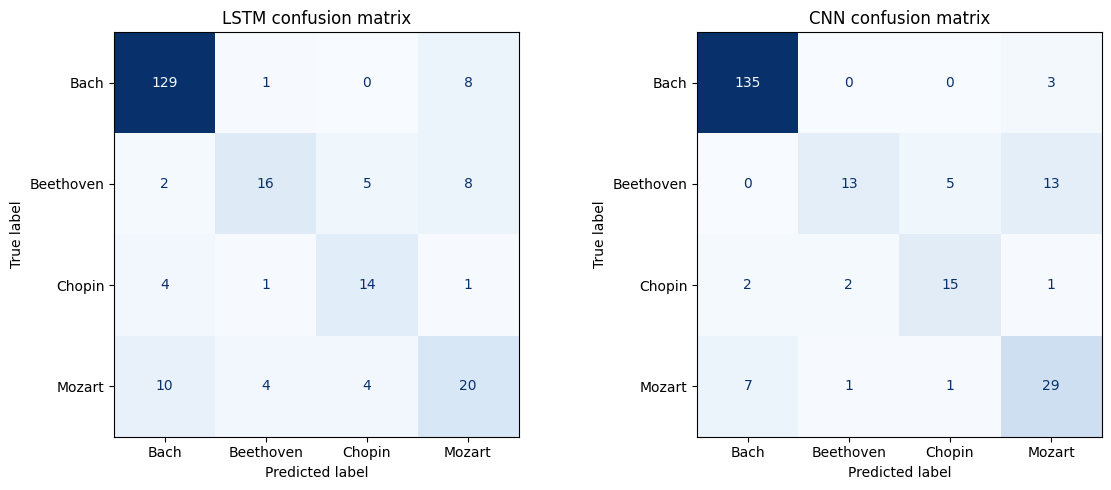

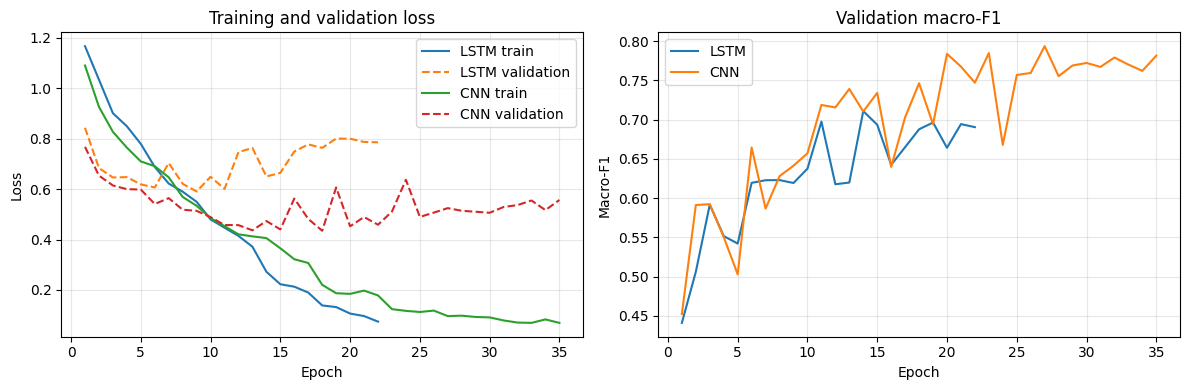

In [33]:
# Compare model performance by generating test classification reports,
# confusion matrices, and training/validation learning curves.

for model_name, metrics in test_results.items():
    print("\n" + "=" * 72)
    print(f"{model_name} TEST CLASSIFICATION REPORT")
    print("=" * 72)
    print(
        classification_report(
            metrics["targets"],
            metrics["predictions"],
            target_names=composer_names,
            digits=4,
            zero_division=0,
        )
    )

print()

# Confusion matrices.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, (model_name, metrics) in zip(axes, test_results.items()):
    matrix = confusion_matrix(metrics["targets"], metrics["predictions"])
    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=composer_names,
    ).plot(ax=axis, cmap=plt.cm.Blues, colorbar=False)
    axis.set_title(f"{model_name} confusion matrix")
plt.tight_layout()
plt.savefig(SEPARATE_MODEL_DIR / "confusion_matrices.png", dpi=150)
plt.show()
print()

# Training curves.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name, history in training_histories.items():
    axes[0].plot(history["epoch"], history["train_loss"],
                 label=f"{model_name} train")
    axes[0].plot(
        history["epoch"],
        history["val_loss"],
        linestyle="--",
        label=f"{model_name} validation",
    )
    axes[1].plot(
        history["epoch"],
        history["val_macro_f1"],
        label=model_name,
    )

axes[0].set_title("Training and validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Validation macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SEPARATE_MODEL_DIR / "training_comparison.png", dpi=150)
plt.show()